In [5]:
import sys
sys.path.append('../')
sys.path.append('../..')

In [6]:
import numpy as np
from sklearn.preprocessing import normalize
import matplotlib.pyplot as plt
import matplotlib
import pandas as pd
from pp.src.proj_dirs import *

In [17]:
ls

__pycache__/                          plot-appendix-reproduce.ipynb
lambda-var-plots/                     plot-synth-and-real-reproduce.ipynb
lambda-var-real                       plot-synth-and-real-varylambda.ipynb
lambda-var-real.pkl                   plot-synth-varylambda.ipynb
lambda-var-synth-tstar.pkl            run.py
lambda-var-synth.pkl                  runreal-lambda.py
main_runner_synthetic.py              runsynth-lambda.py
maxg_maxeps_ours.ipynb                syn-t1-our_vs_jorg.pdf
medcost-t1-our_vs_jorg.pdf            syn-t1-our_vs_jorg_std.pdf
medcost-t1-our_vs_jorg_std.pdf        syn-t1-our_vs_sdp.pdf
medcost-t1-our_vs_sdp.pdf             syn-t2-our_vs_jorg.pdf
medcost-t2-our_vs_jorg.pdf            syn-t2-our_vs_jorg_std.pdf
medcost-t2-our_vs_jorg_std.pdf        syn-t2-our_vs_sdp.pdf
medcost-t2-our_vs_sdp.pdf             syn-thetadiff.pdf


In [7]:
## PLOT configs
plt.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'font.size' : 15,                   # Set font size to 11pt
    'axes.labelsize': 15,               # -> axis labels
    'xtick.labelsize':12,
    'ytick.labelsize':12,
    'legend.fontsize': 12,
    'lines.linewidth':2,
    'text.usetex': False,
    'pgf.rcfonts': False,
})
# plt.tight_layout(rect=[0, 0.03, 1, 0.85])

In [19]:
ls "../../output/insurance"

lambda-var.pkl


In [20]:
df = pd.read_pickle("../../output/insurance/lambda-var.pkl")

In [22]:
df.lamb.unique()

array([1.0e-02, 2.0e-02, 3.0e-02, 4.0e-02, 5.0e-02, 6.0e-02, 7.0e-02,
       8.0e-02, 9.0e-02, 1.0e-01, 2.0e-01, 3.0e-01, 4.0e-01, 5.0e-01,
       6.0e-01, 7.0e-01, 8.0e-01, 9.0e-01, 1.0e+00, 1.5e+00, 2.0e+00,
       2.5e+00, 3.0e+00, 4.0e+00, 5.0e+00, 1.0e+01, 2.5e+01, 5.0e+01,
       7.5e+01, 1.0e+02])

In [28]:
df.columns

Index(['runs', 'ttsplit', 'lamb', 'frac_train', 'f_c', 'f_m', 'eps_c', 'eps_m',
       'eps_l', 'type1_nonpriv_loss',
       ...
       't2_thetadiff_maxg_mean', 't2_thetadiff_maxg_std',
       't2_maxeps_train_mean', 't2_maxeps_train_std', 't2_maxeps_test_mean',
       't2_maxeps_test_std', 't2_thetahat_maxeps_mean',
       't2_thetahat_maxeps_std', 't2_thetadiff_maxeps_mean',
       't2_thetadiff_maxeps_std'],
      dtype='object', length=106)

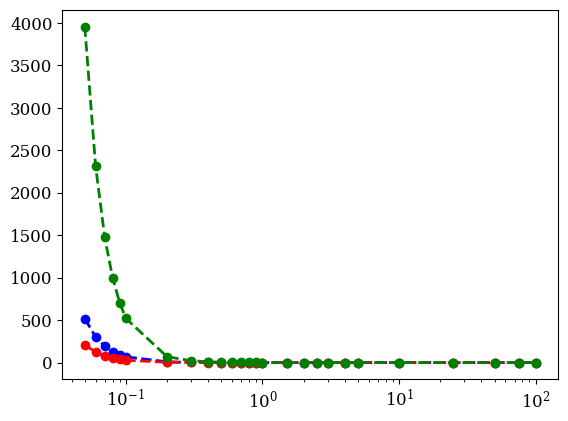

In [38]:
plt.xscale('log')
si = 4 # start index
plt.plot(df['lamb'][si:], df['t1_oa_test_mean'][si:], '--bo') # our pdp
plt.plot(df['lamb'][si:], df['t1_maxeps_test_mean'][si:], '--ro') # max eps lower bound for loss, not actually PDP!
plt.plot(df['lamb'][si:], df['t1_maxg_test_mean'][si:], '--go') #  max group, discards eps which are not epsilon high